Code to plot the location of vortex ring cores during formation for a range of conditions.

These plots should be similar to Didden figure 5

Plots to make:
r against z
r against t
z against t
normalised injection time like I did for circulation
core expansion rate - so that I can later define some Rossby criterion.

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
# dirPath = "C:/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)


####Import Ollie Tools MAC
dirPath = "/Users/olliejackson/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)

oj.thesis_plot_settings()
print(plt.rcParams["figure.dpi"])


# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')

vels = h5file['Narrow']['U50']['L50']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
#normalise location about the axis of rotation
VortLocMin[:,0] = np.subtract(VortLocMin[:,0], int(u.shape[1]/2))
VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))


/Users/olliejackson/Coding
Thesis plot settings applied
400.0


Initial plot to show what it looks like:
two cores 

2.7148
27.442168852217474


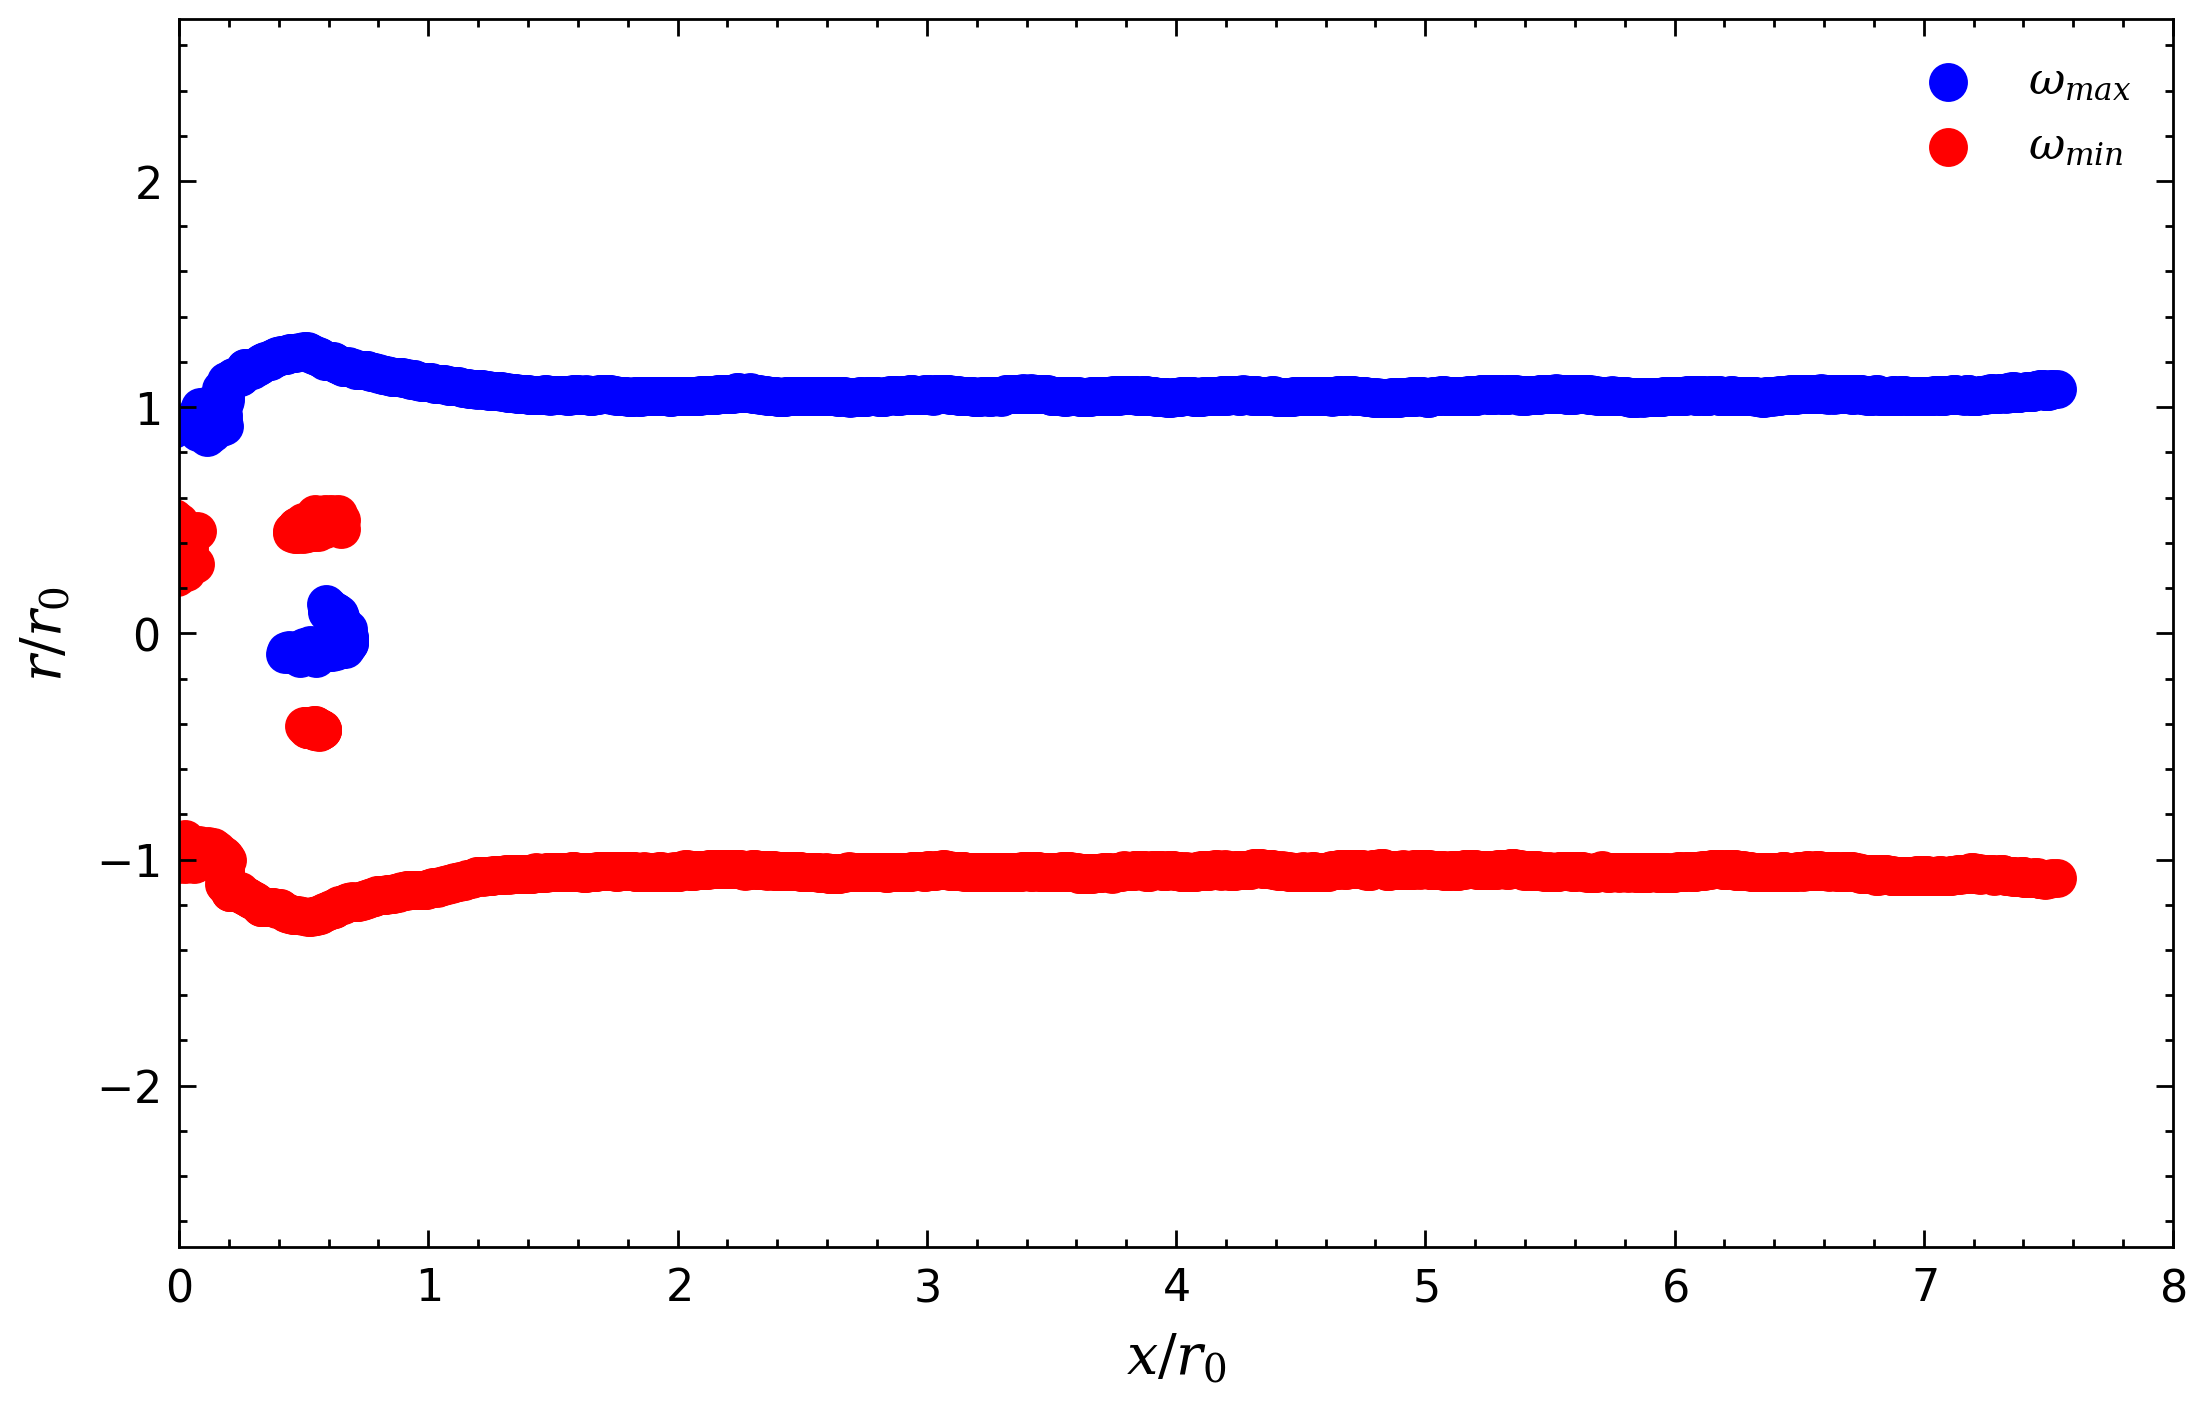

In [25]:

# f1, ax1 = plt.subplots(1, 1, figsize=(5.5, 3.5))
# ax1.scatter(Time[81:530]-8/9, VortLocMax[81:530,0], label=r'$\omega_{max}$ Location', color='b')
# ax1.scatter(Time[81:530]-8/9, VortLocMin[81:530,0], label=r'$\omega_{min}$ Location', color='r')
# ax1.set_xlabel('Time (s)')
# ax1.set_ylabel('r')
# ax1.legend(fontsize=8)
# plt.show()

print(r_nd[-1])
r_factor = u.shape[1]/(2*r_nd[-1])
print(r_factor)

f2, ax2 = plt.subplots(1, 1, figsize=(5.5, 3.5))
# ax2.scatter(VortLocMax[81:530,1]/r_factor-1, VortLocMax[81:530,0]/r_factor, label=r'$\omega_{max}$ Location', color='b')
# ax2.scatter(VortLocMin[81:530,1]/r_factor-1, VortLocMin[81:530,0]/r_factor, label=r'$\omega_{min}$ Location', color='r')
ax2.scatter(VortLocMax[81:,1]/r_factor-1, VortLocMax[81:,0]/r_factor, label=r'$\omega_{max}$ ', color='b')
ax2.scatter(VortLocMin[81:,1]/r_factor-1, VortLocMin[81:,0]/r_factor, label=r'$\omega_{min}$ ', color='r')
ax2.set_ylim(-2.7148, 2.7148)
# ax2.set_xlim(0, 2.5)
ax2.set_xlim(0,8)
ax2.set_xlabel(r'$x/r_{0}$')
ax2.set_ylabel(r'$r/r_{0}$')
ax2.legend(fontsize=8)
plt.show()

show the comparison of the two absolute values 

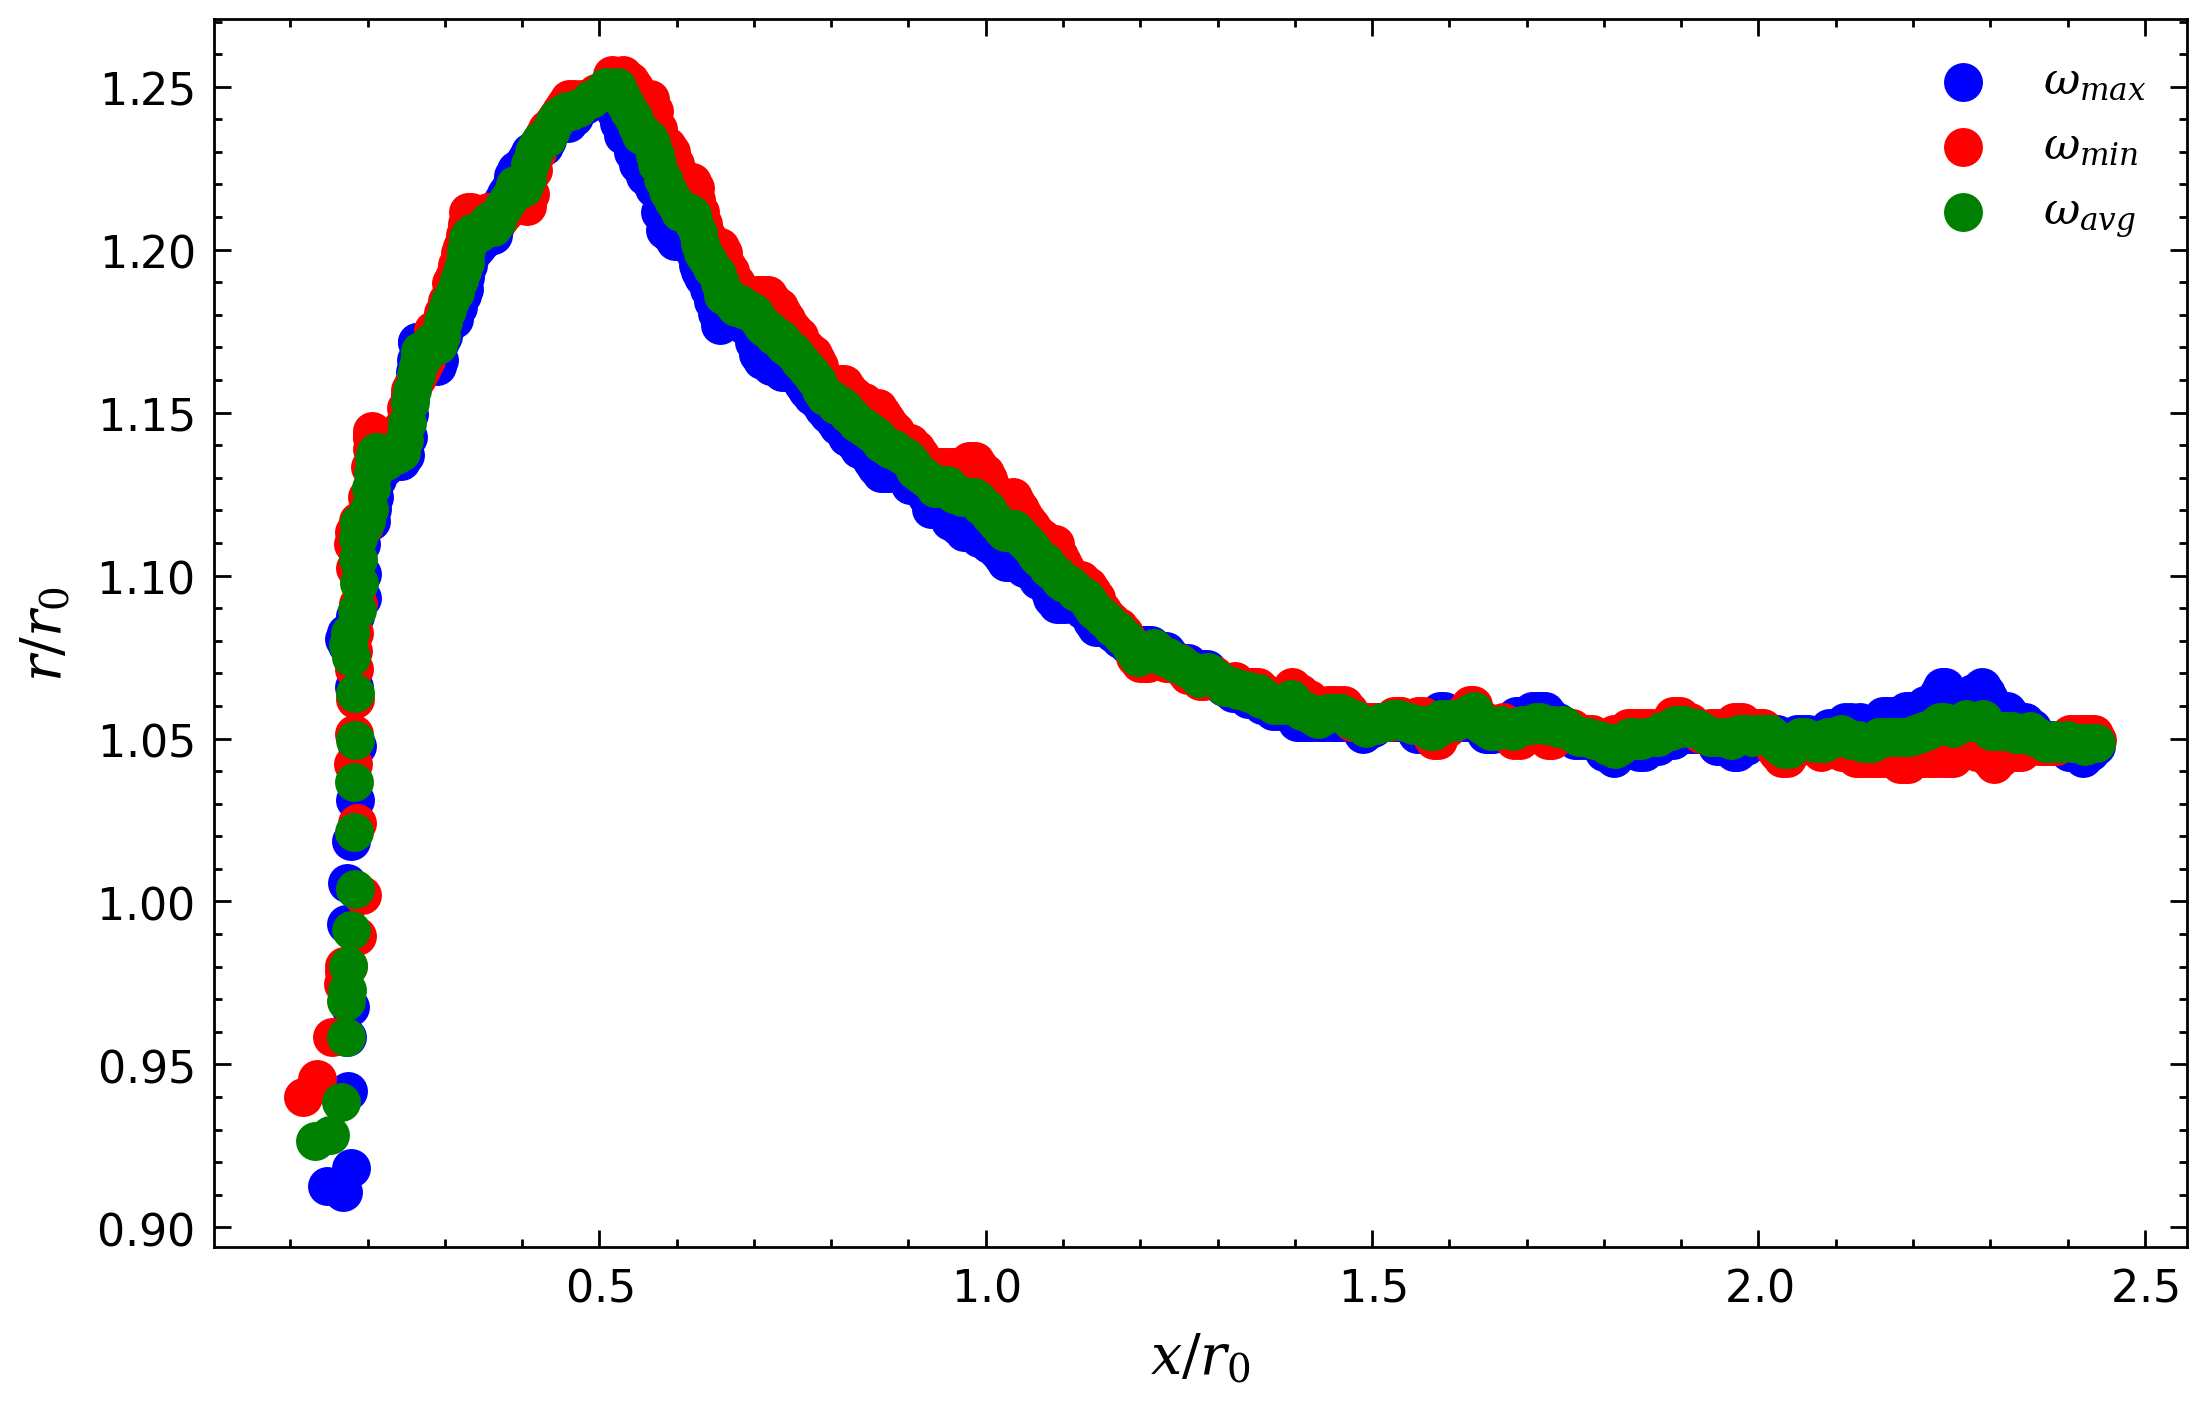

In [19]:
VortLocMin = abs(VortLocMin)
VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)


f2, ax2 = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax2.scatter(VortLocMax[81:530,1]/r_factor-1, VortLocMax[81:530,0]/r_factor, label=r'$\omega_{max}$', color='b')
ax2.scatter(VortLocMin[81:530,1]/r_factor-1, VortLocMin[81:530,0]/r_factor, label=r'$\omega_{min}$', color='r')
ax2.scatter(VortLocAvg[81:530,1]/r_factor-1, VortLocAvg[81:530,0]/r_factor, label=r'$\omega_{avg}$', color='g')
ax2.set_xlabel(r'$x/r_{0}$')
ax2.set_ylabel(r'$r/r_{0}$')
ax2.legend(fontsize=8)
plt.show()

Now to plot the averages of different conditions against each other:

use length test data here to get more conditions

the argument at the end of this will be that we can normalise by injection time maybe????

In [14]:
# h5file = h5py.File('E:/H5/LengthTestNEW.h5', 'r')
h5file = h5py.File('E:/H5/LengthTest.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

vels = h5file['Narrow']['U100']['L50']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
h5file.close()

50
0
1
100
0
1


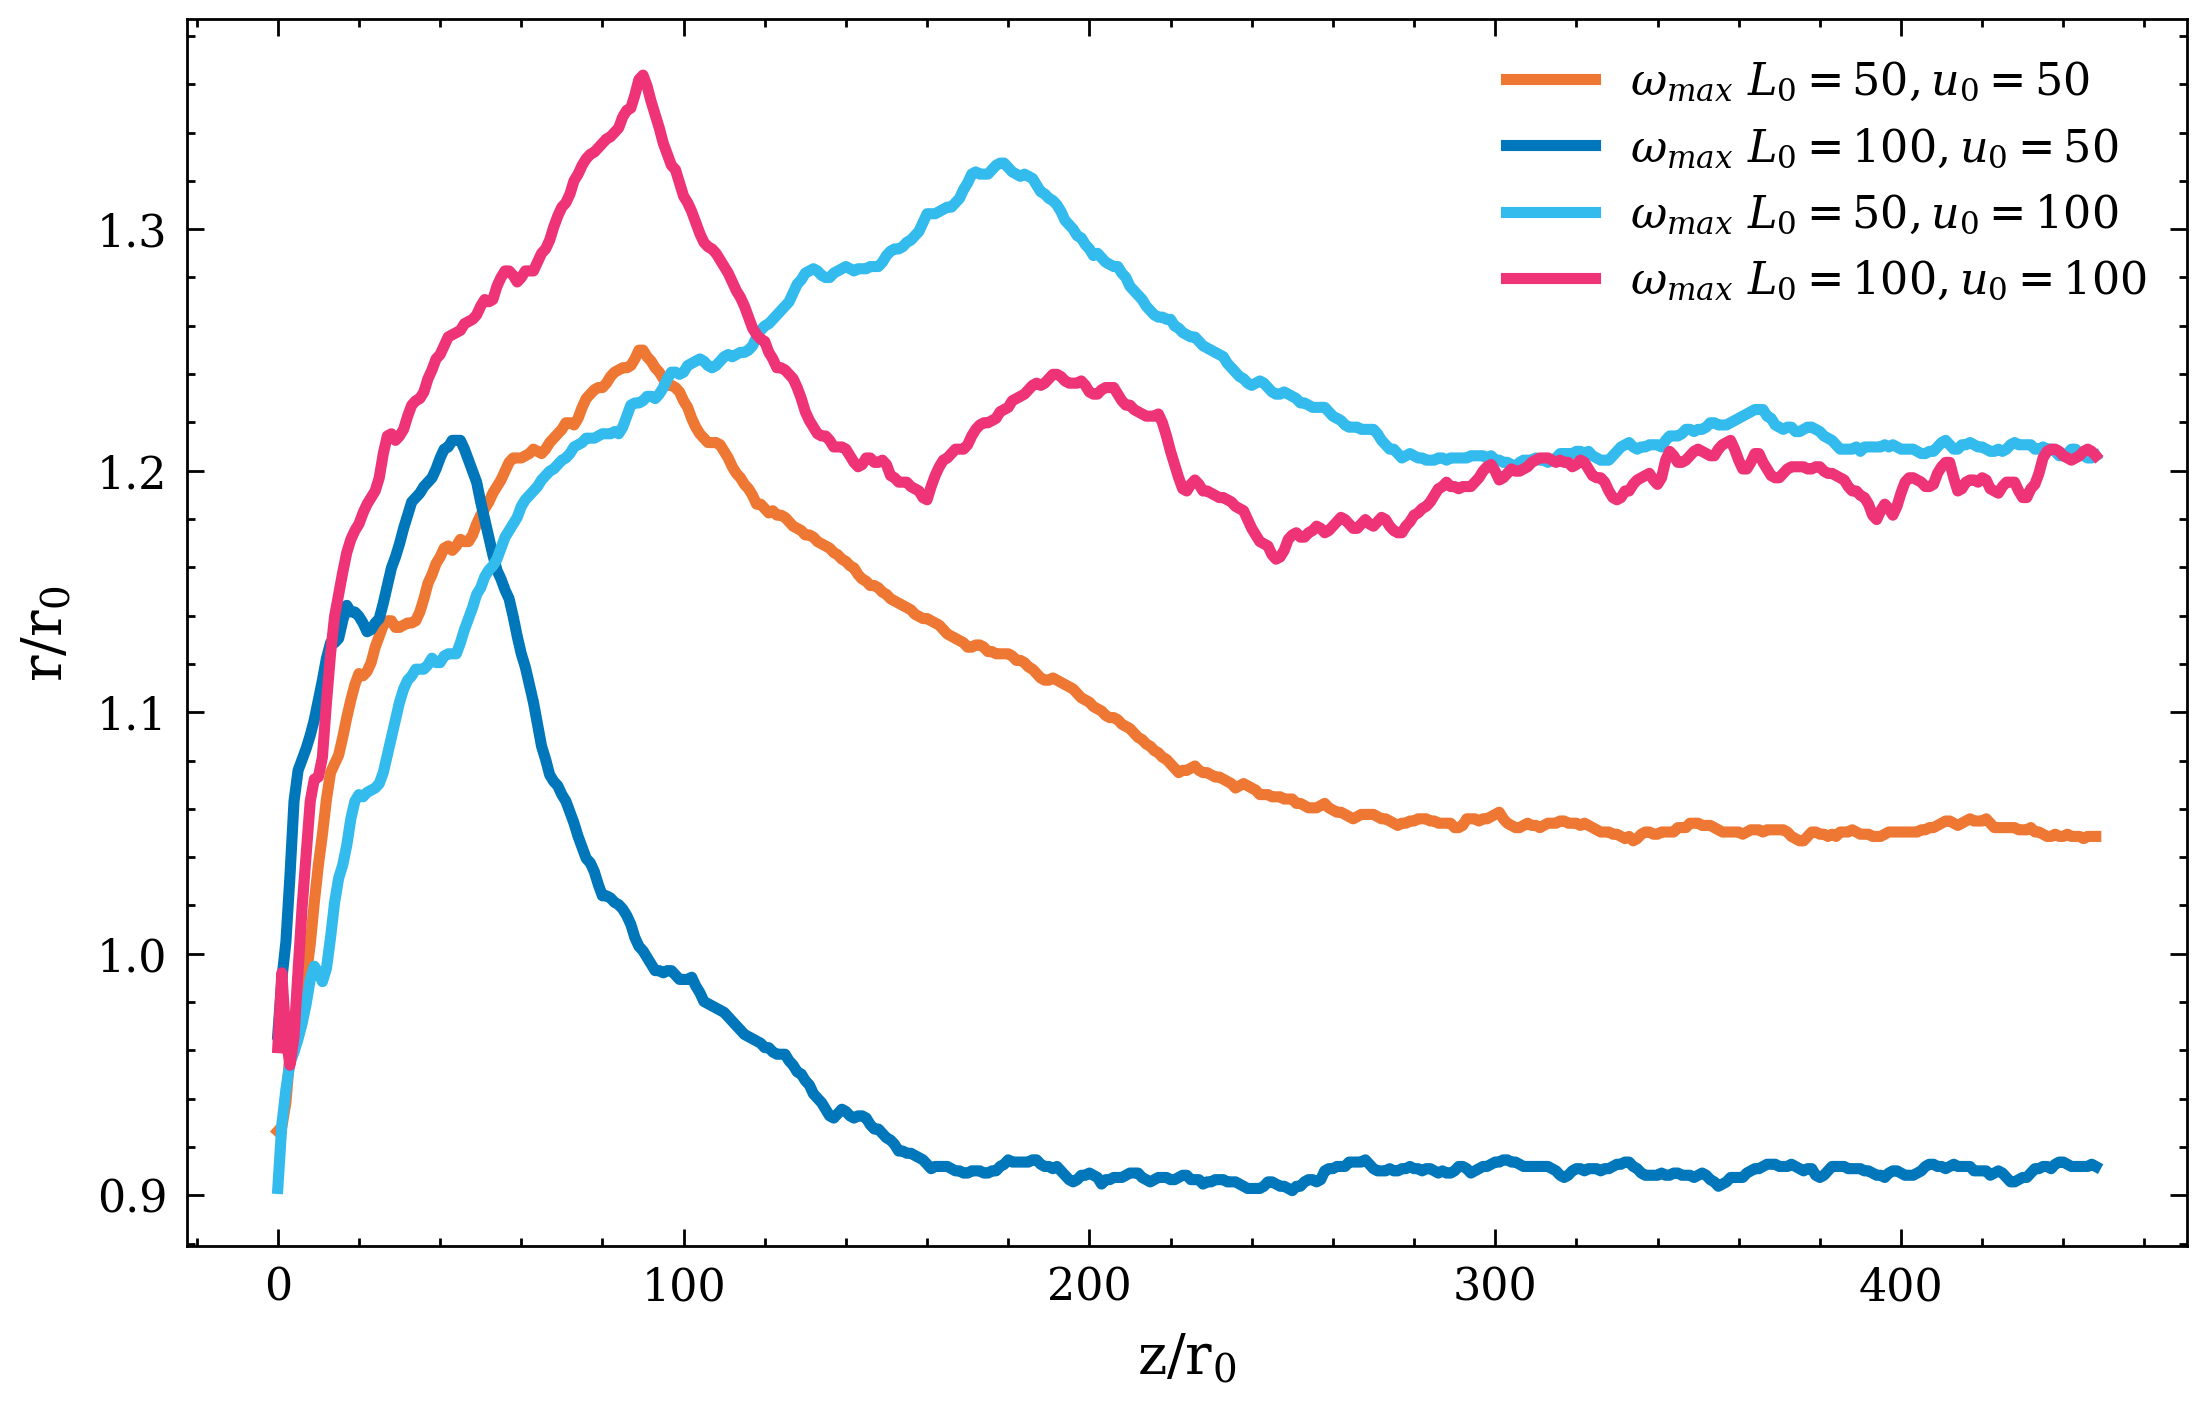

In [15]:
lengths = np.array([25, 50, 75, 100, 125, 150, 175, 200, 225, 240])
# h5file = h5py.File('E:/H5/LengthTest.h5', 'r')
h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
# lengths = np.array([50, 100])
# oj.descend_obj(h5file)
lengths = np.array([50, 100])
velocities = np.array([50, 100])
index = 0


fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

for i in range(lengths.shape[0]):
    print(str(lengths[i]))
    for j in range(velocities.shape[0]):
        print(j)

        # vels = h5file['Narrow']['U100'][f'L{str(lengths[index])}']['RPM0']
        vels = h5file['Narrow']['U'+str(velocities[j])]['L'+str(lengths[i])]['RPM0']
        u = vels[:,:,:,0]
        v = vels[:,:,:,1]
        u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
        VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
        #normalise location about the axis of rotation
        VortLocMin[:,0] = abs(np.subtract(VortLocMin[:,0], int(u.shape[1]/2)))
        VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))
        VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)
        ax.plot(VortLocAvg[81:530,0]/r_factor, label=r'$\omega_{max}$' + f' $L_{0}={str(velocities[j])}, u_{0}={str(lengths[i])}$')

ax.set_xlabel(r'z/r$_{0}$')
ax.set_ylabel(r'r/r$_{0}$')
ax.legend(fontsize=8)
plt.show()

Comparing the same ring with different rotation rates r against z:

['infinity', 1.02e-05, 5.1e-06, 3.4e-06, 1.7e-06, 1.1e-06, 8.5e-07]


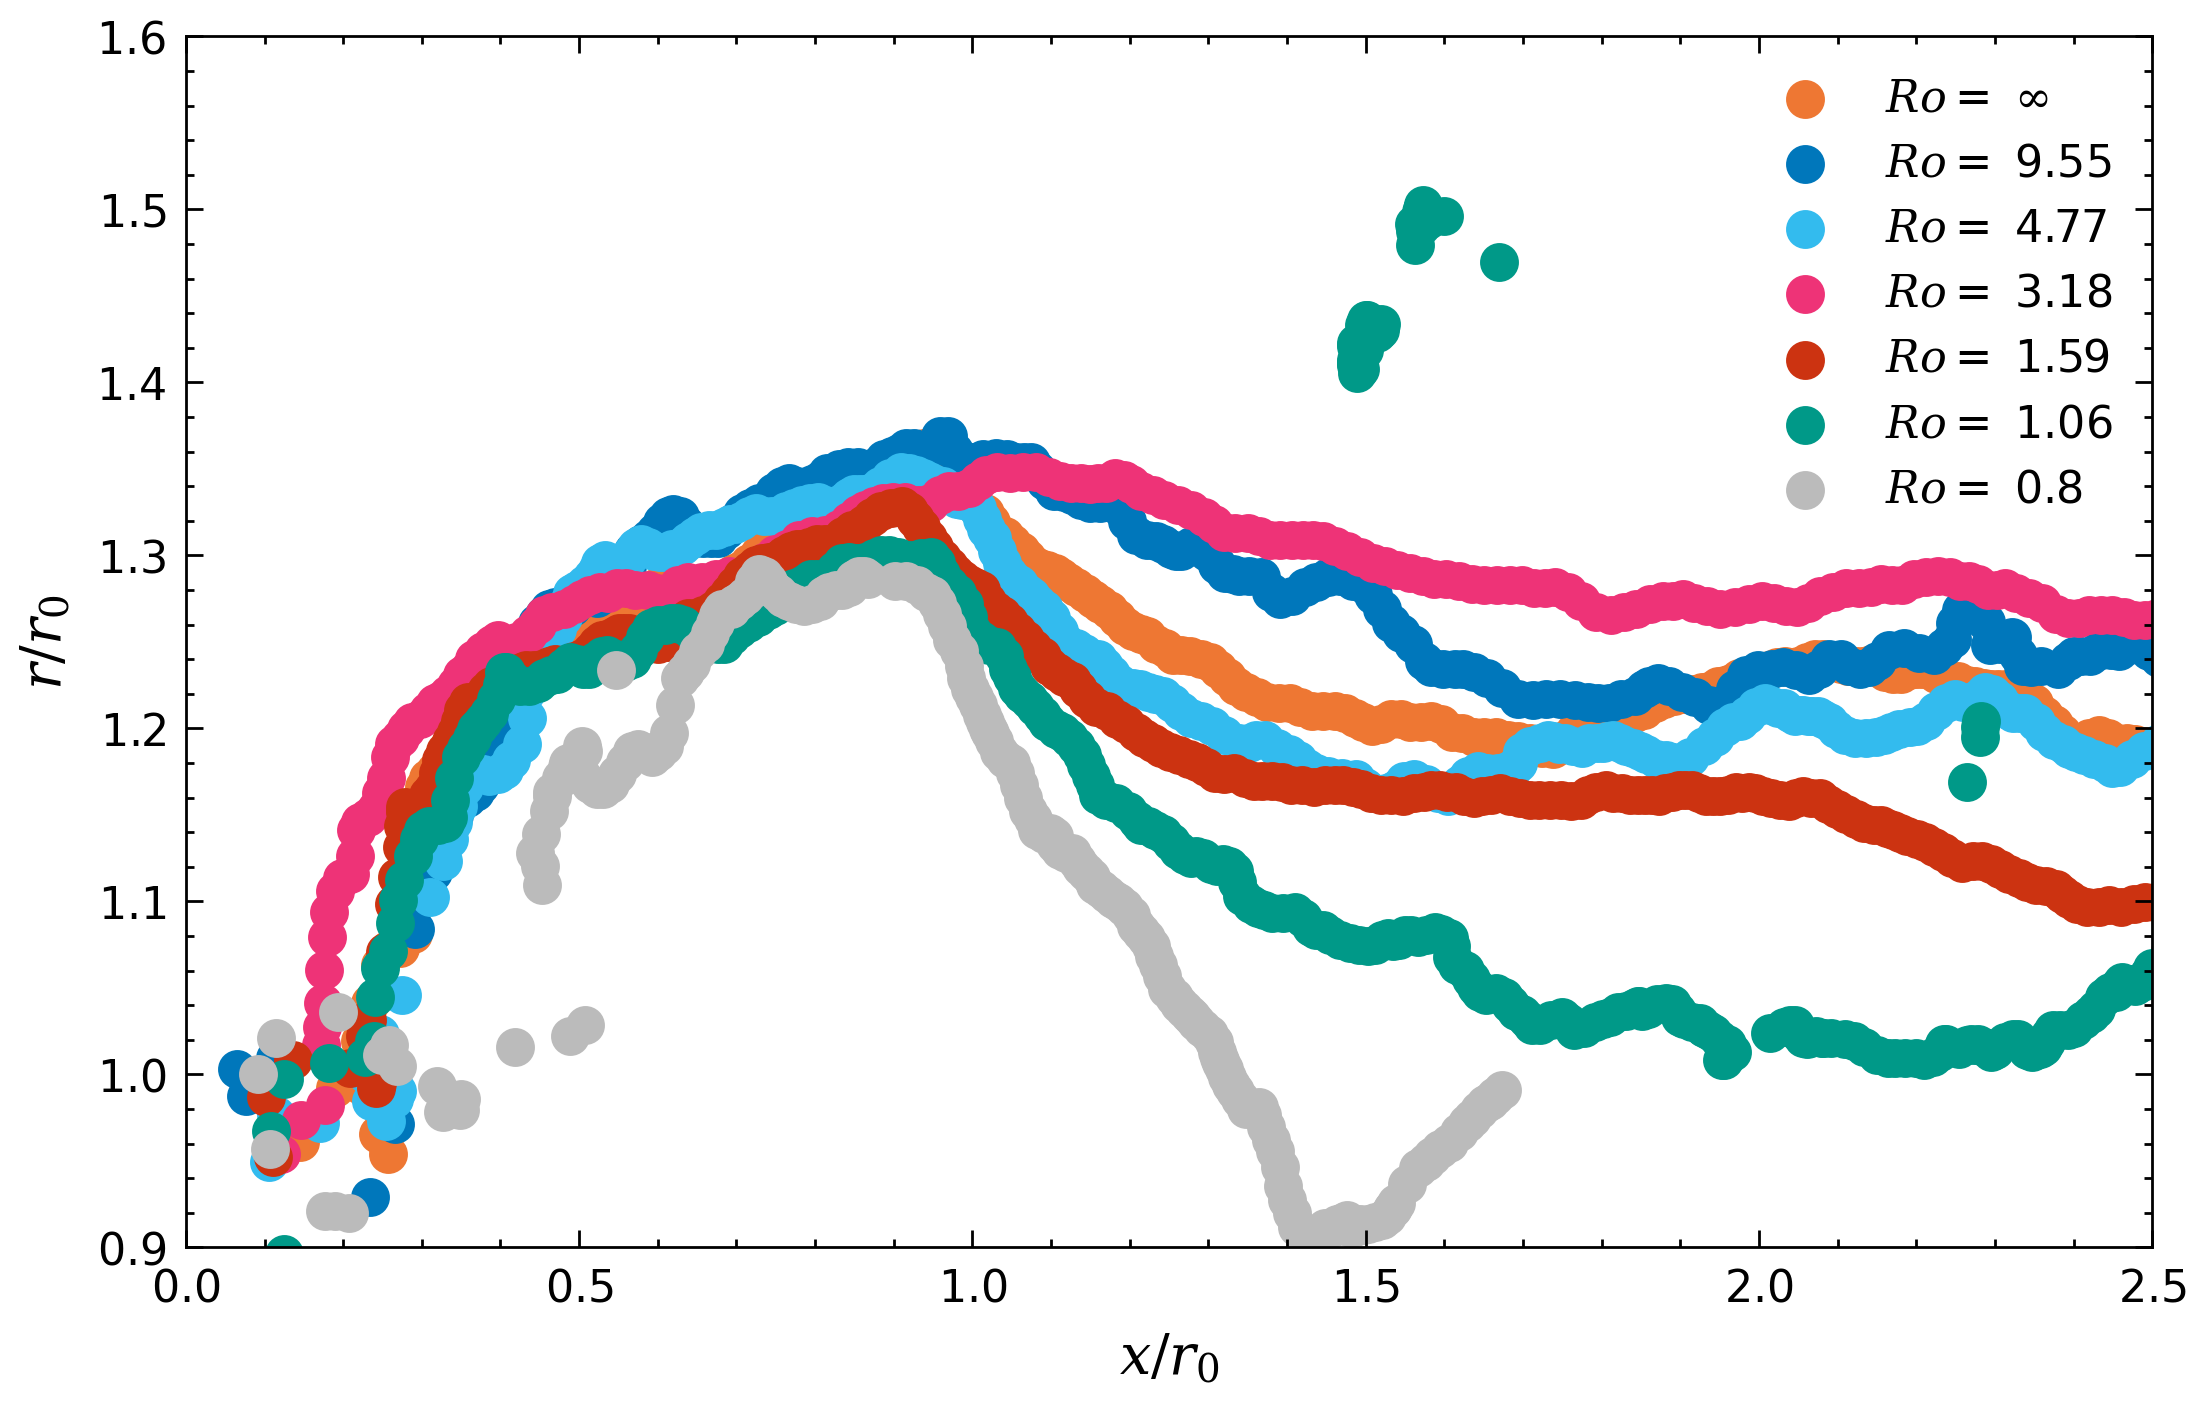

In [26]:

# h5file = h5py.File('E:/H5/LengthTest.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
# oj.descend_obj(h5file)
rpms = np.array([0, 1, 2, 3, 6, 9, 12])
eks = Eks = ['infinity', 0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

print(eks)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

for i in range(rpms.shape[0]):
# for i in range(2):

    vels = h5file['Narrow']['U100']['L100']['RPM'+str(rpms[i])]
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
    VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
    #normalise location about the axis of rotation
    VortLocMin[:,0] = abs(np.subtract(VortLocMin[:,0], int(u.shape[1]/2)))
    VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))
    VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)
    # ax.scatter(VortLocAvg[81:530,1]/r_factor-1, VortLocAvg[81:530,0]/r_factor, label=f'$Ek$ = {str(Eks[i])}')
    ax.scatter(VortLocAvg[81:530,1]/r_factor-1, VortLocAvg[81:530,0]/r_factor, label=f'$Ro =$ {oj.Ro(0.1, rpms[i])}')

ax.set_xlabel(r'$x/r_{0}$')
ax.set_ylabel(r'$r/r_{0}$')
ax.legend(fontsize=8)
ax.set_ylim(0.9, 1.6)
ax.set_xlim(0, 2.5)
plt.show()

Comparing the same ring with different rotation rates z against t:

['infinity', 1.02e-05, 5.1e-06, 3.4e-06, 1.7e-06, 1.1e-06, 8.5e-07]
0
1
2
3
4
5
6


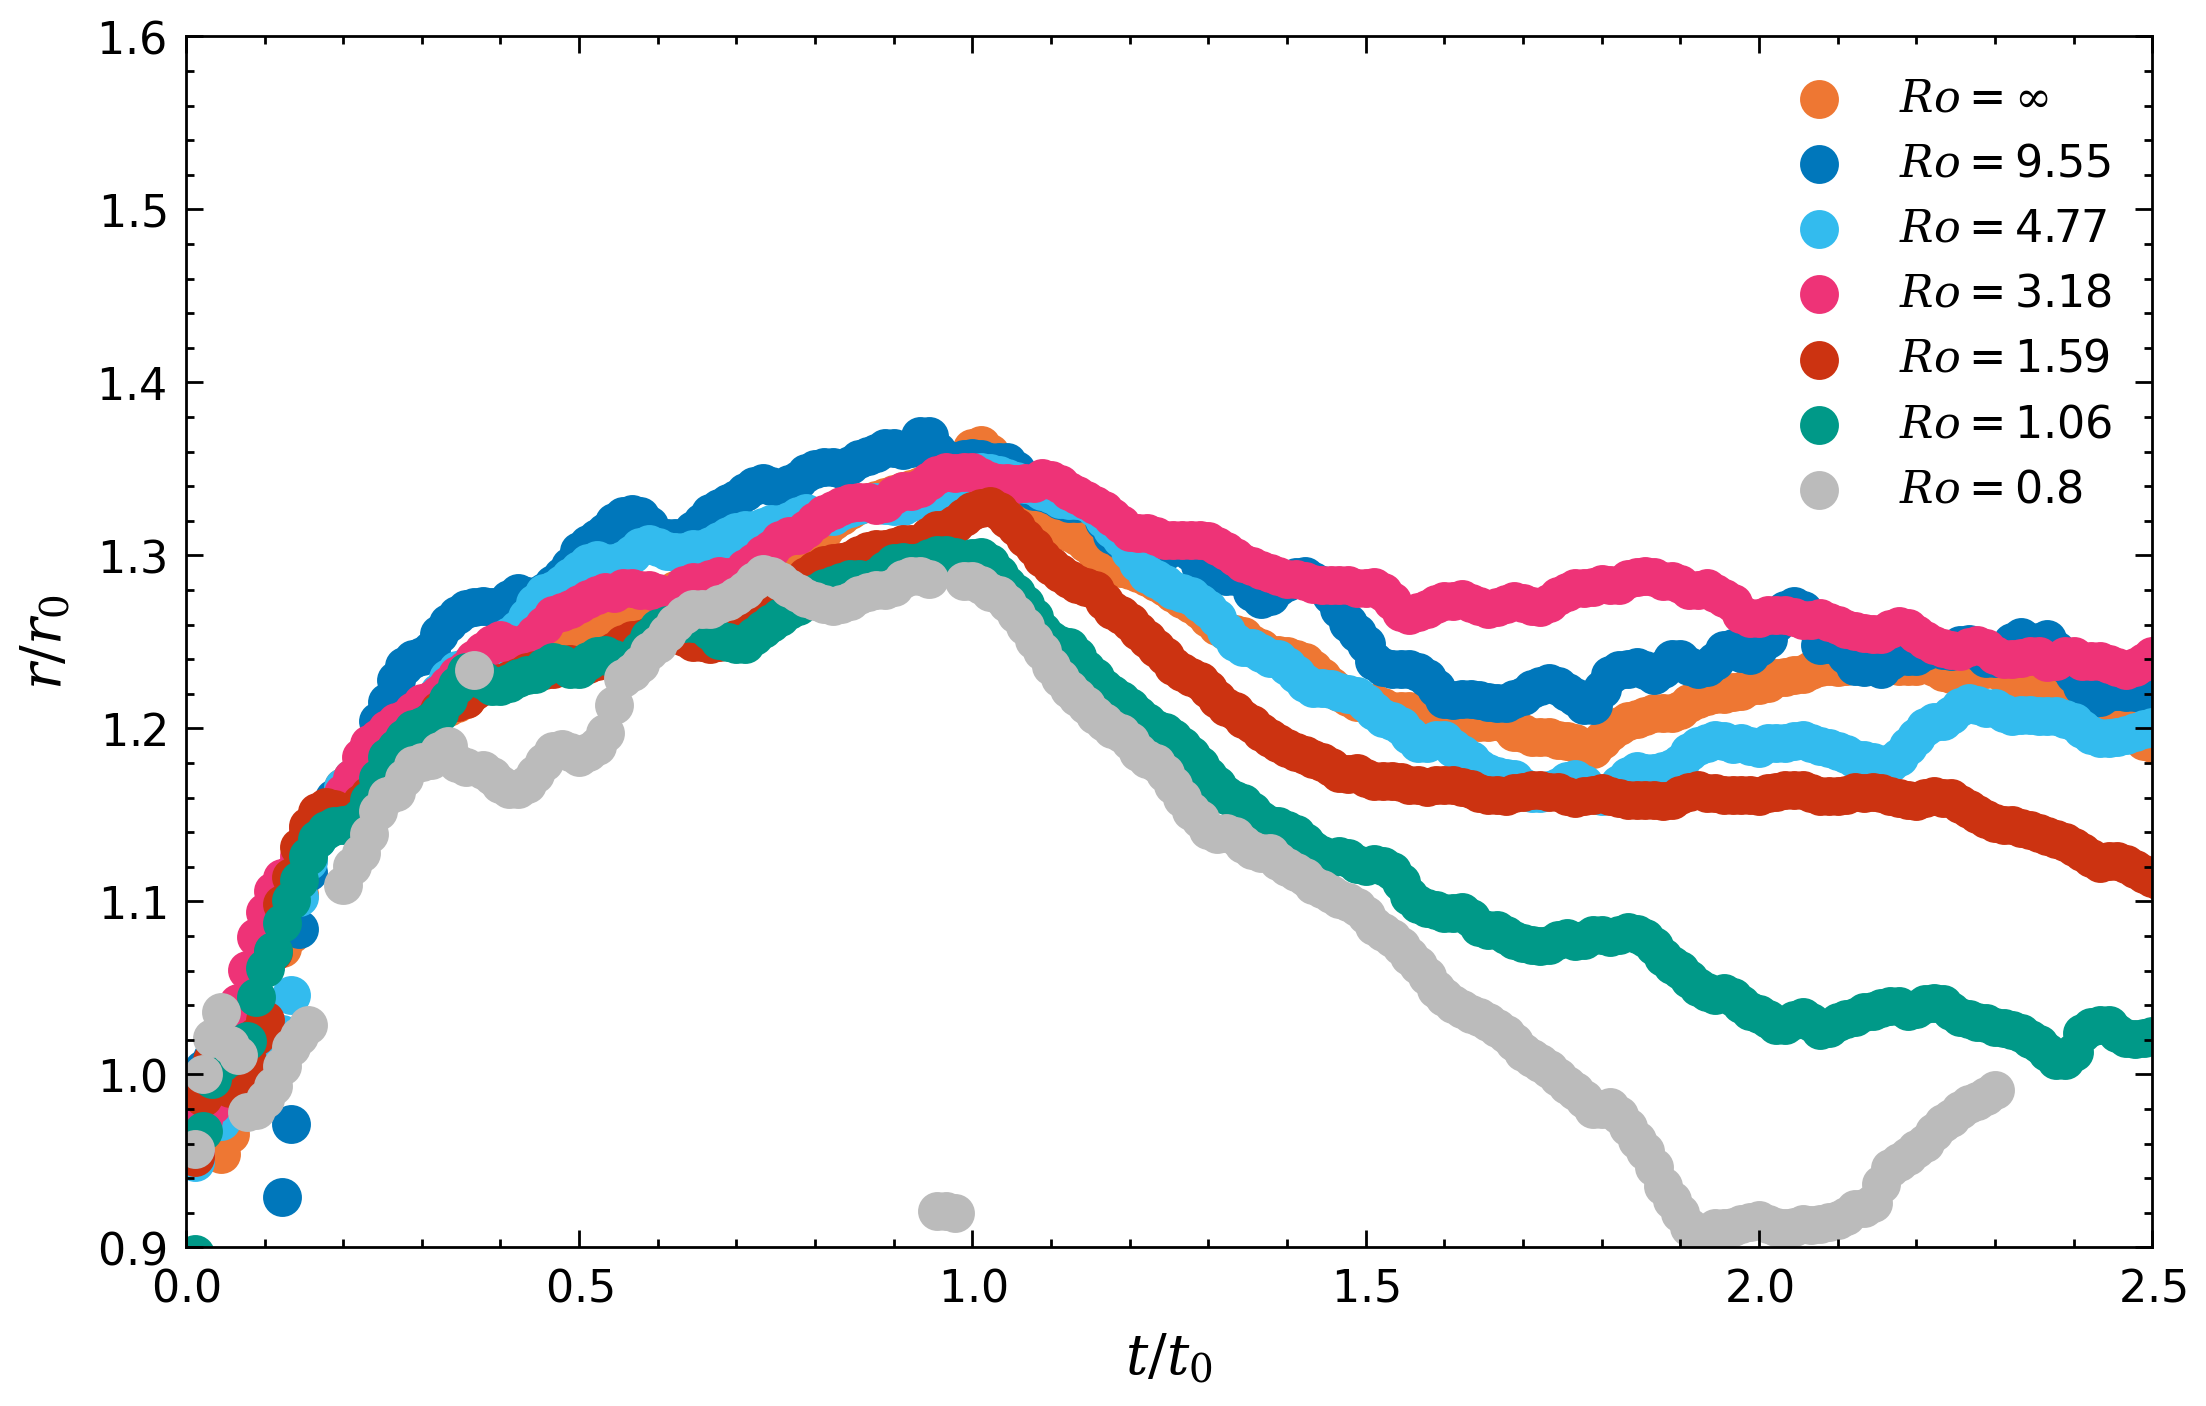

In [27]:

# h5file = h5py.File('E:/H5/LengthTest.h5', 'r')
# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
# oj.descend_obj(h5file)
rpms = np.array([0, 1, 2, 3, 6, 9, 12])
eks = Eks = ['infinity', 0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

print(eks)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

for i in range(rpms.shape[0]):
# for i in range(2):

    print(i)
    vels = h5file['Narrow']['U100']['L100']['RPM'+str(rpms[i])]
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
    VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
    #normalise location about the axis of rotation
    VortLocMin[:,0] = abs(np.subtract(VortLocMin[:,0], int(u.shape[1]/2)))
    VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))
    VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)
    # ax.scatter(Time[81:530]-8/9, VortLocAvg[81:530,0]/r_factor, label=f'$Ek$ = {str(Eks[i])}')
    ax.scatter(Time[81:530]-8/9, VortLocAvg[81:530,0]/r_factor, label=f'$Ro = ${str(oj.Ro(0.1, rpms[i]))}')

ax.set_xlabel(r'$t/t_{0}$')
ax.set_ylabel(r'$r/r_{0}$')
ax.legend(fontsize=8)
ax.set_ylim(0.9, 1.6)
ax.set_xlim(0, 2.5)
plt.show()

Now to load in different injection conditions with the same rotation rates normalised by time, such that the injection time is normalised to see if there is a rossby based difference.

In [18]:
vels = h5file['Narrow']['U50']['L100']['RPM6']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
#normalise location about the axis of rotation
VortLocMin[:,0] = abs(np.subtract(VortLocMin[:,0], int(u.shape[1]/2)))
VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))
VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)

start_frame = 81
end_frame = 530


t_inj = np.argmax(VortLocAvg[start_frame:end_frame,0])/90
t_star, t_end_star = oj.normalise_injection_time(u[start_frame:end_frame,:,:], v[start_frame:end_frame,:,:])

t_inj:  1.0777777777777777
end_frame_star:  561


0.9888888888888889
33.724999999999994
0.45555555555555555
37.35
1.988888888888889
35.974999999999994
1.0
37.0


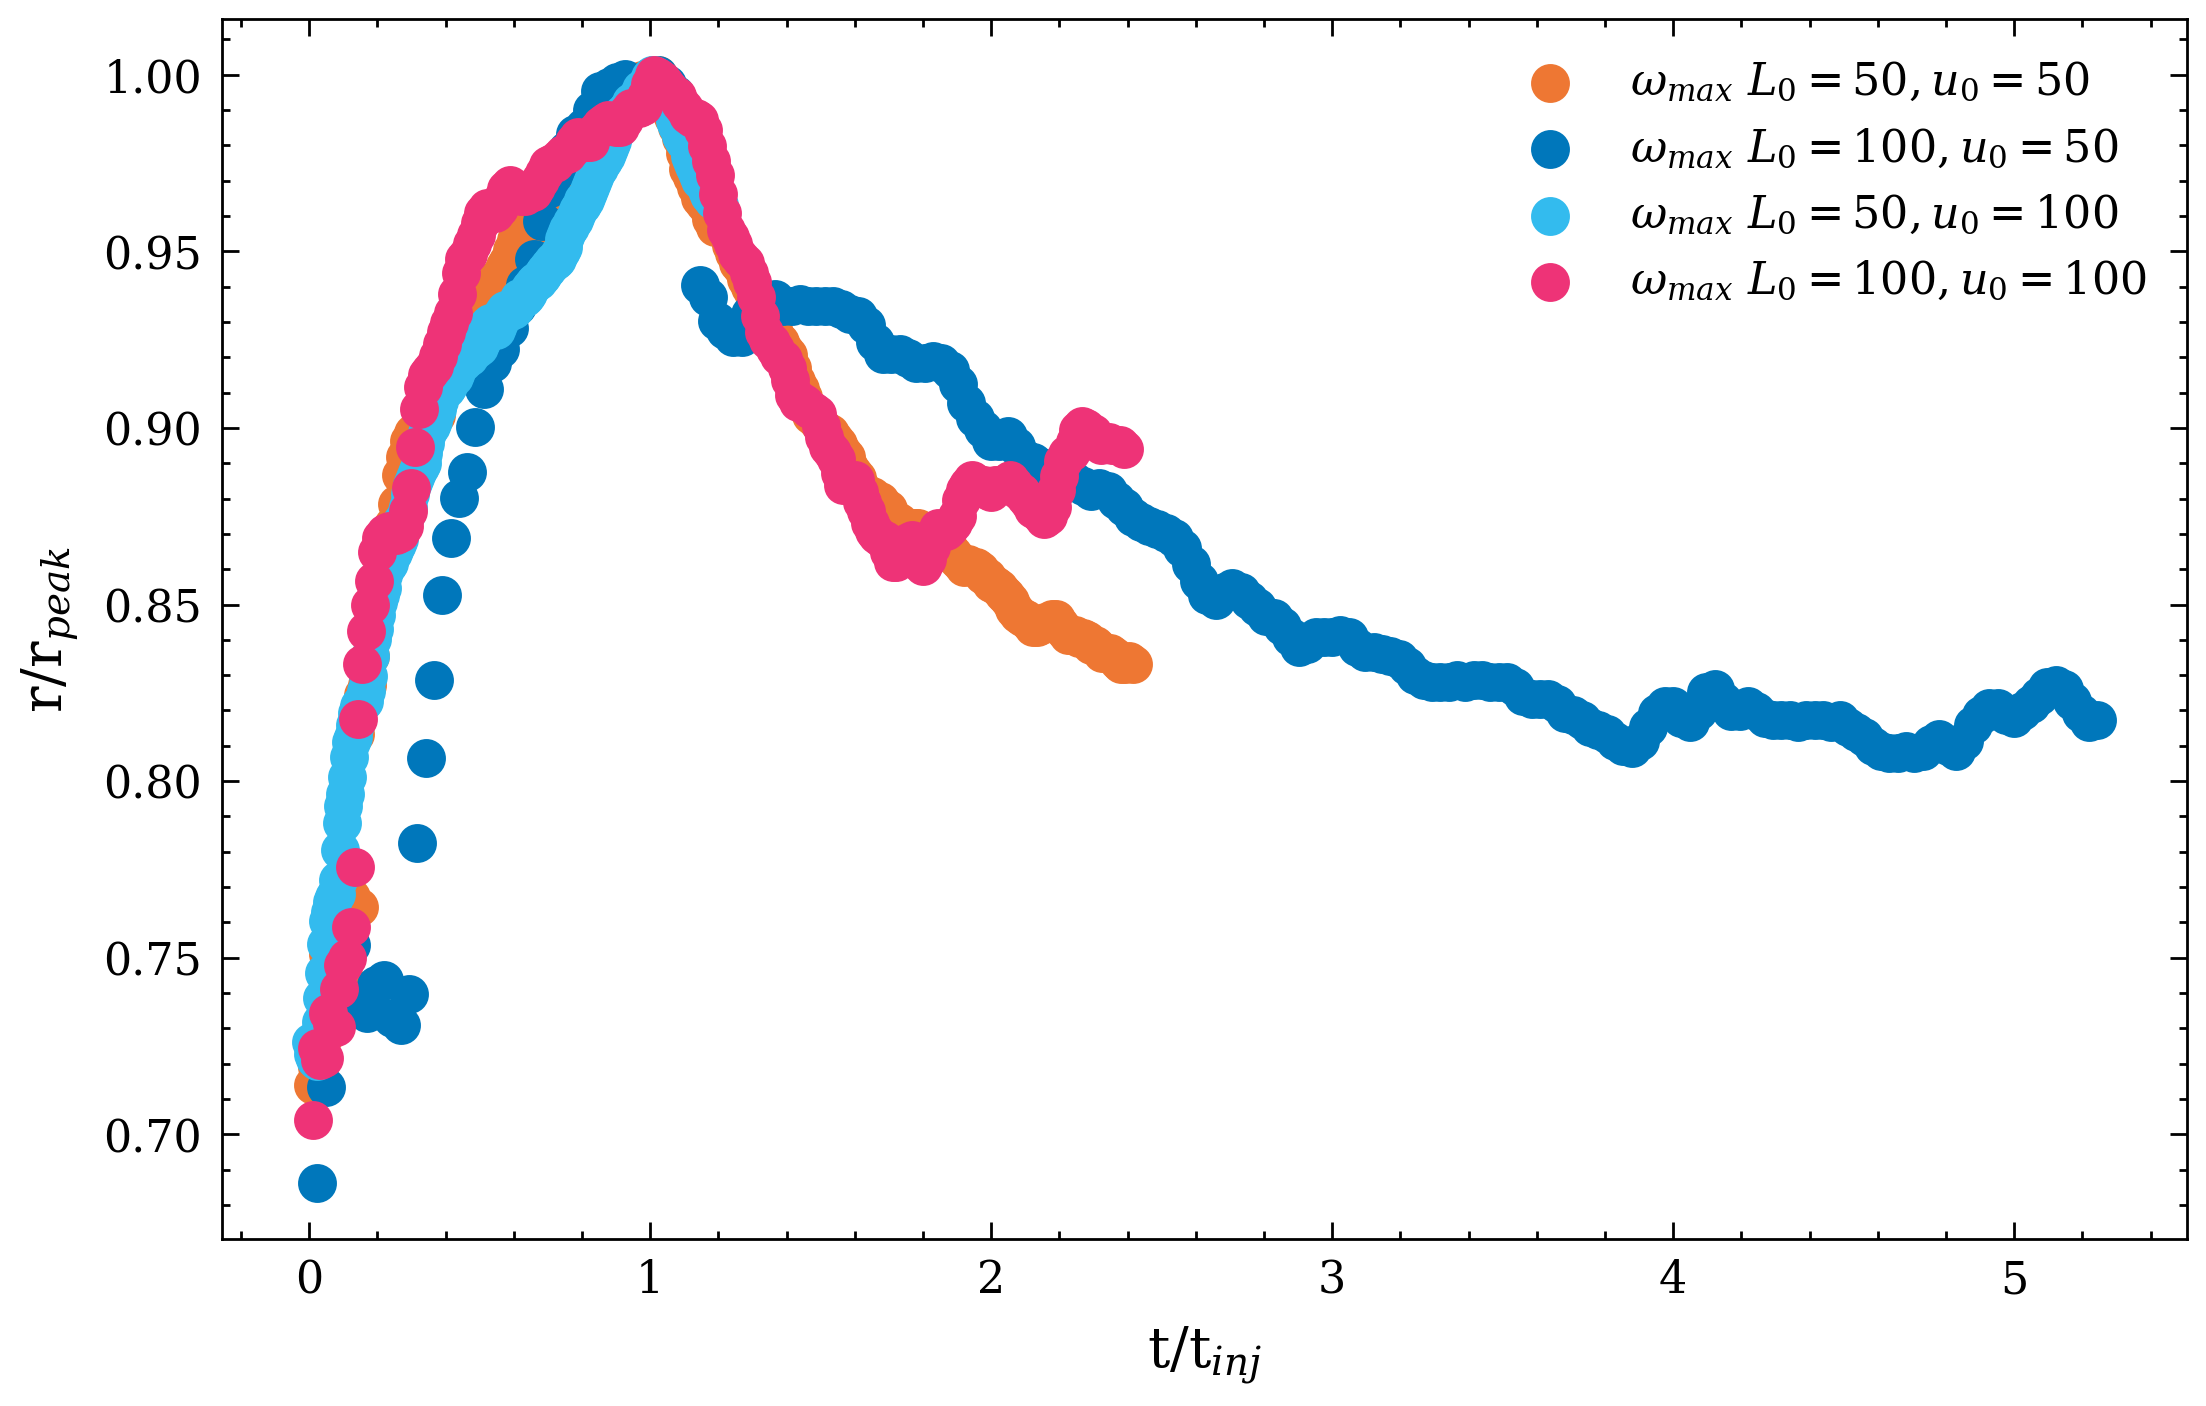

In [27]:

lengths = np.array([25, 50, 75, 100, 125, 150, 175, 200, 225, 240])
# h5file = h5py.File('E:/H5/LengthTest.h5', 'r')
h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
lengths = np.array([50, 100])
velocities = np.array([50, 100])

maxima = np.array([34.3, 33.275, 36.425,37.425])
start_frame = 81
index = 0
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

for i in range(lengths.shape[0]):
    for j in range(velocities.shape[0]):
# for i in range(0):
#     for j in range(0):

        vels = h5file['Narrow']['U'+str(velocities[j])]['L'+str(lengths[i])]['RPM2']
        u = vels[:,:,:,0]
        v = vels[:,:,:,1]
        u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
        VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial

        #normalise location about the axis of rotation
        VortLocMin[:,0] = abs(np.subtract(VortLocMin[:,0], int(u.shape[1]/2)))
        VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))
        VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)
        t_inj = np.argmax(VortLocAvg[start_frame:end_frame,0])/90
        print(t_inj)
        print(np.max(VortLocAvg[81:end_frame,0]))
        # ax.plot(VortLocAvg[81:530,0]/r_factor, label=r'$\omega_{max}$' + f' $L_{0}={str(velocities[j])}, u_{0}={str(lengths[i])}$')
        normalised_r = (VortLocAvg[start_frame:end_frame,0]/np.max(VortLocAvg[start_frame:end_frame,0]))
        # normalised_r = (VortLocAvg[start_frame:end_frame,0]/maxima[index])
        ax.scatter((Time[start_frame:end_frame]-8/9)/t_inj, normalised_r, label=r'$\omega_{max}$'+ f' $L_{0}={str(velocities[j])}, u_{0}={str(lengths[i])}$')
        index += 1
ax.set_xlabel(r't/t$_{inj}$')
ax.set_ylabel(r'r/r$_{peak}$')
ax.legend(fontsize=8)
# ax.set_ylim(0, 1.3)
# ax.set_xlim(0, 2.5)
plt.show()

Ring Expansion rate:
* convolved smoothing
* derivitive against time
* see how this changes with different rotaion rates as with the last plot.

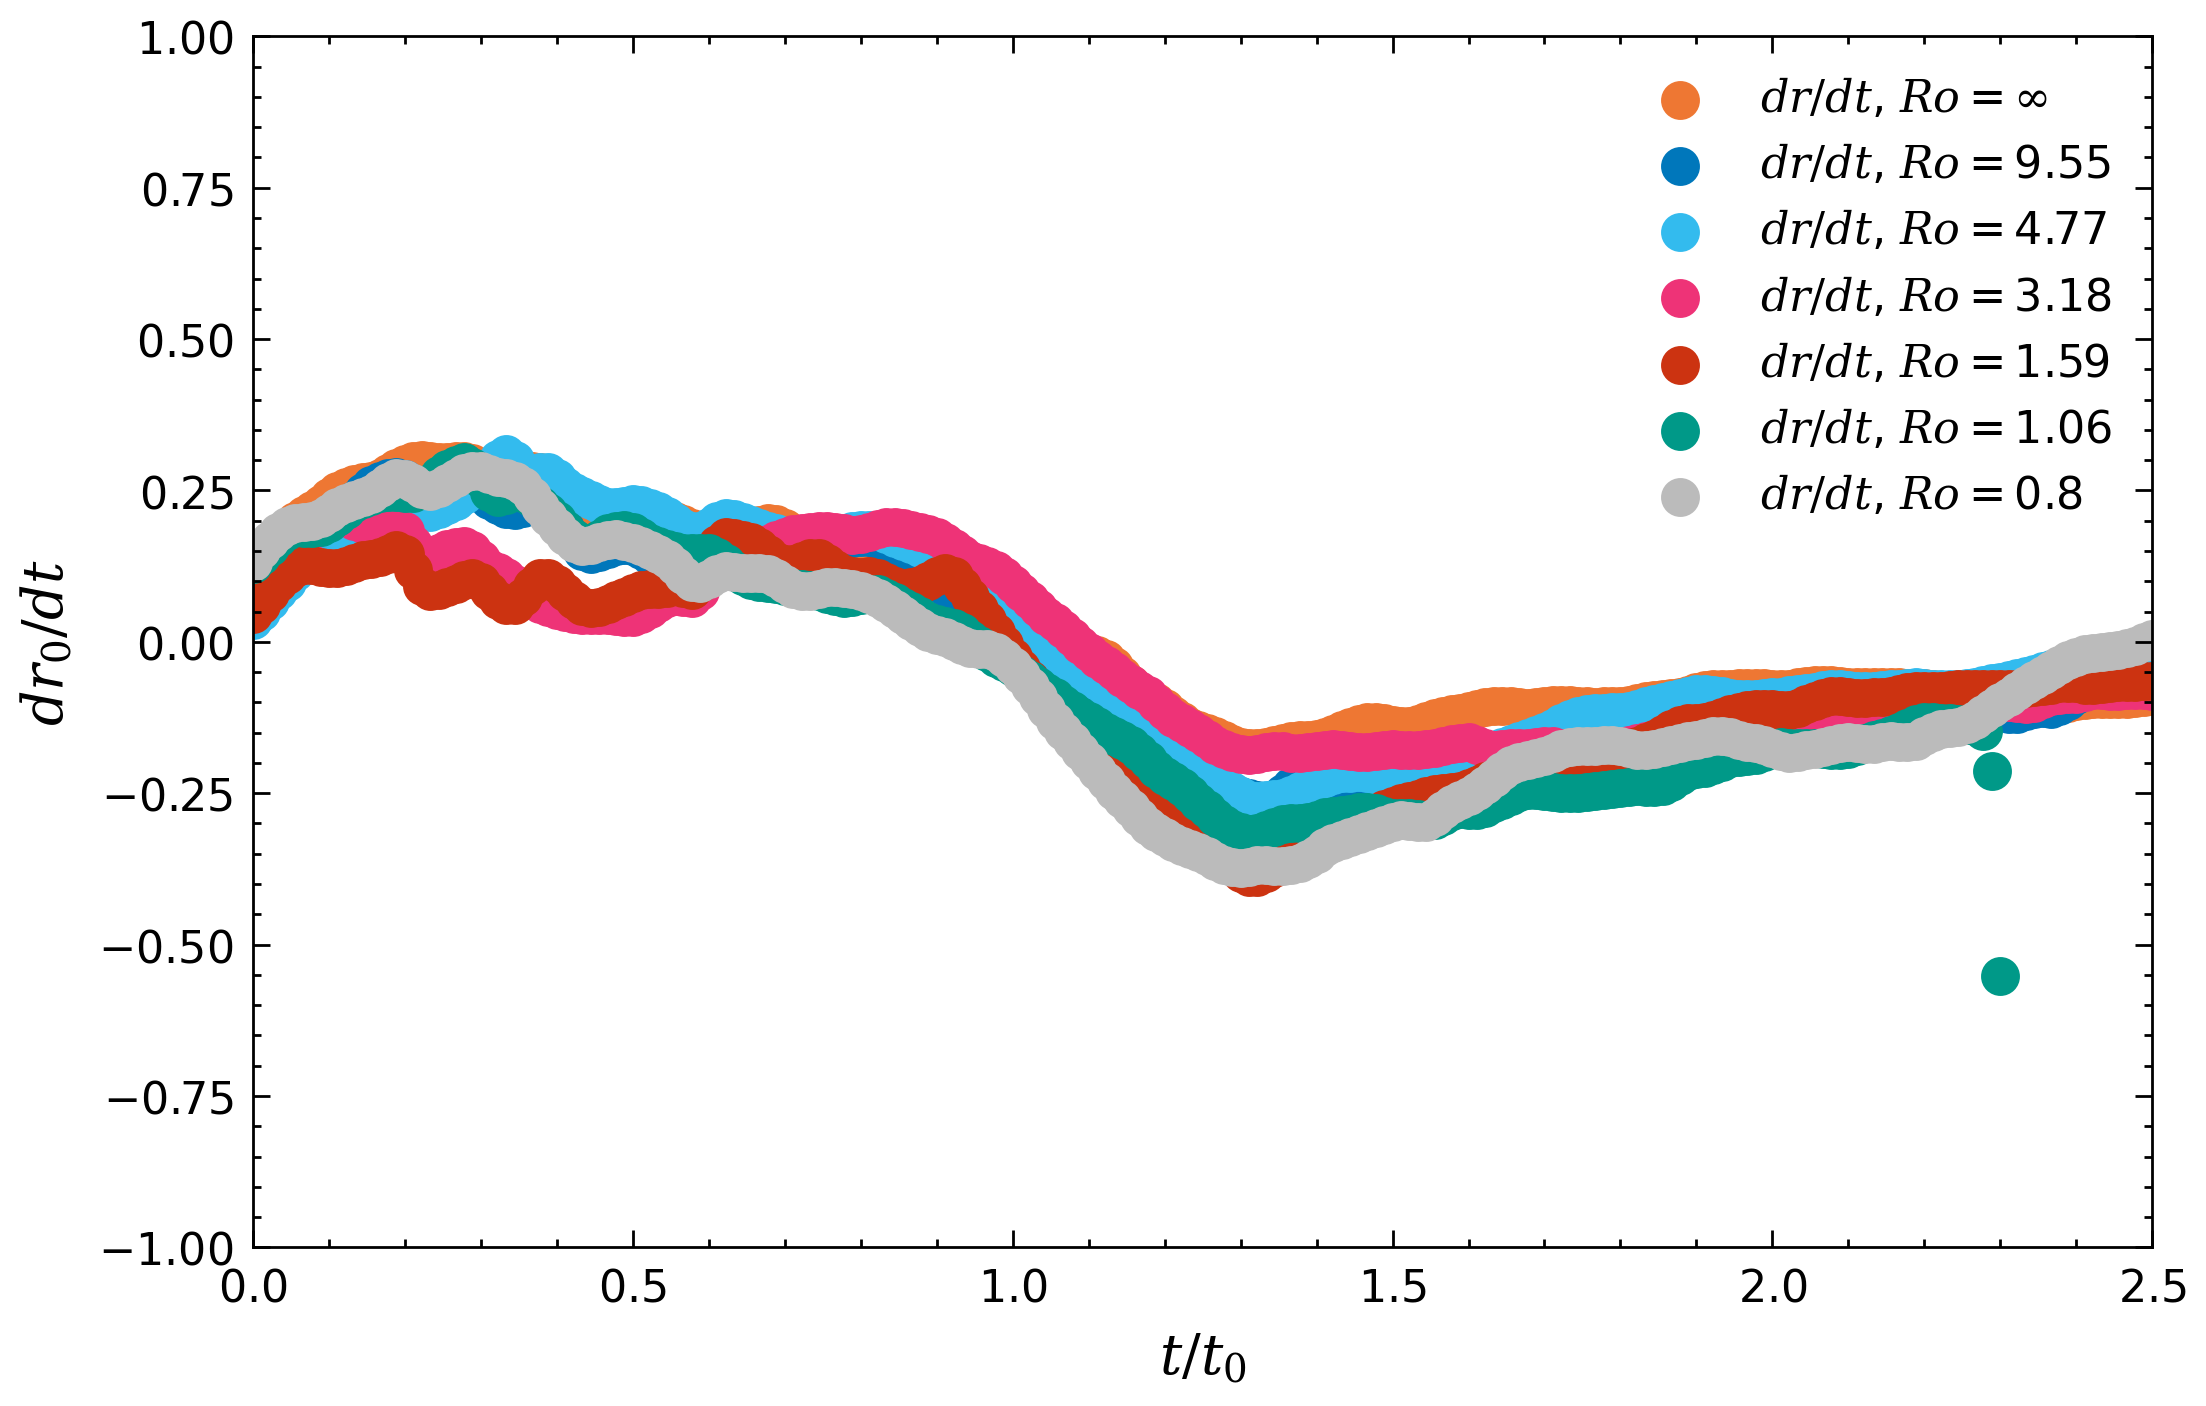

In [28]:

# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/meandataVLSFine.h5', 'r')
lengths = np.array([50, 100])
velocities = np.array([50, 100])
rpms = np.array([0, 1, 2, 3, 6, 9, 12])
start_frame = 71
end_frame = 296

def convolved_derivitive(y, x, len = 15): 
    '''
    Convolved derivitive of a function dy/dx with length len coresponing to the number of points to average over
    len must be odd
    '''
    filt = np.ones(len)/len
    # print(len)
    # print(filt)
    y_smooth = np.convolve(y, filt, mode='valid')
    # dysdx = np.gradient(y_smooth, x[5:-5])
    # print(len/2, " = len/2")
    # print(int(len/2), " = int len/2")
    dysdx = np.gradient(y_smooth, x[int(len/2):-int(len/2)])

    return dysdx

from scipy.ndimage import gaussian_filter

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

# for i in range(lengths.shape[0]):
#     for j in range(velocities.shape[0]):
# # for i in range(1):
# #     for j in range(1):

#         vels = h5file['Narrow']['U'+str(velocities[j])]['L'+str(lengths[i])]['RPM0']
#         # vels = h5file['Narrow']['U50']['L50']['RPM0']
#         u = vels[:,:,:,0]
#         v = vels[:,:,:,1]
#         u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
#         VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
#         VortLocMax[0:108,0] = 105 #####forcing the radial positon of the core to be at the nozzle (approximately) for the first 108 frames
#         #normalise location about the axis of rotation
#         # VortLocMin[:,0] = abs(np.subtract(VortLocMin[:,0], int(u.shape[1]/2)))
#         # VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))
#         # VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)
#         # t_inj = np.argmax(VortLocMax[start_frame:end_frame,0])/90
        
#         dva = gaussian_filter(convolved_derivitive(VortLocMax[:,0], Time[:],35), 1)
#         # ax.plot(VortLocAvg[81:530,0]/r_factor, label=r'$\omega_{max}$' + f' $L_{0}={str(velocities[j])}, u_{0}={str(lengths[i])}$')
#         ax.plot(Time[start_frame-int(35/2):end_frame], dva[start_frame-int(35/2):end_frame], label=r'$dr/dt$'+ f' $L_{0}={str(velocities[j])}, u_{0}={str(lengths[i])}$')


for i in range(rpms.shape[0]):
# for i in range(1):
    vels = h5file['Narrow']['U50']['L50']['RPM'+str(rpms[i])]
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
    VortLocMax, VortLocMin = oj.vorticityPeakTracking_inter(u[:,:,:], v[:,:,:]) # Axis 0 is radial, axis 1 is axial
    VortLocMax[0:108,0] = 105 #####forcing the radial positon of the core to be at the nozzle (approximately) for the first 108 frames
    #### normalise location about the axis of rotation
    VortLocMin[:,0] = abs(np.subtract(VortLocMin[:,0], int(u.shape[1]/2)))
    VortLocMax[:,0] = np.subtract(VortLocMax[:,0], int(u.shape[1]/2))
    VortLocAvg = np.mean([VortLocMax, VortLocMin], axis = 0)
    VortLocAvg[0:81,0] = 28 #####forcing the radial positon of the core to be at the nozzle (approximately) for the first 108 frames
    # t_inj = np.argmax(VortLocMax[start_frame:end_frame,0])/90
    
    dva = convolved_derivitive(gaussian_filter(VortLocAvg[:,0], 1), Time[:],35)
    # ax.plot(VortLocAvg[81:530,0]/r_factor, label=r'$\omega_{max}$' + f' $L_{0}={str(velocities[j])}, u_{0}={str(lengths[i])}$')
    # ax.scatter(Time[start_frame-int(35/2):end_frame]-0.6, dva[start_frame-int(35/2):end_frame]/r_factor, label=r'$dr/dt$, '+ f'$Ek$ = {str(Eks[i])}')
    ax.scatter(Time[start_frame-int(35/2):end_frame]-0.6, dva[start_frame-int(35/2):end_frame]/r_factor, label=r'$dr/dt$, '+ f'$Ro = ${oj.Ro(0.1, rpms[i])}')
    # ax.plot(VortLocAvg[start_frame:end_frame,0])

ax.set_xlabel(r'$t/t_{0}$')
ax.set_ylabel(r'$dr_{0}/dt$')
ax.legend(fontsize=8)
ax.set_ylim(-1, 1)
ax.set_xlim(0, 2.5)
plt.show()